In [5]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy
from tqdm import tqdm


In [9]:
data = np.load("xsuite_dataset.npz")

X = data["X"]  # shape (N, 6)
Y = data["Y"]  # shape (N, 6)

print("Original X shape:", X.shape)
print("Original Y shape:", Y.shape)


randomize_indices = np.random.permutation(X.shape[0])
X = X[randomize_indices]
Y = Y[randomize_indices]


into_train = int(0.5 * X.shape[0])

X_train = torch.tensor(X[:into_train], dtype=torch.float32)
Y_train = torch.tensor(Y[:into_train], dtype=torch.float32)
X_val = torch.tensor(X[into_train:], dtype=torch.float32)
Y_val = torch.tensor(Y[into_train:], dtype=torch.float32)

print("Training set shapes:", X_train.shape, Y_train.shape)
print("Test set shapes:", X_val.shape, Y_val.shape)


Original X shape: (50000, 6)
Original Y shape: (50000, 6)
Training set shapes: torch.Size([25000, 6]) torch.Size([25000, 6])
Test set shapes: torch.Size([25000, 6]) torch.Size([25000, 6])


In [10]:
def normalize_pair(X_train, Y_train, X_val, Y_val, eps=1e-12):
    X_mean = X_train.mean(0, keepdim=True)
    X_std  = X_train.std(0, keepdim=True) + eps

    Y_mean = Y_train.mean(0, keepdim=True)
    Y_std  = Y_train.std(0, keepdim=True) + eps

    X_train_n = (X_train - X_mean) / X_std
    X_val_n   = (X_val   - X_mean) / X_std
    Y_train_n = (Y_train - Y_mean) / Y_std
    Y_val_n   = (Y_val   - Y_mean) / Y_std

    stats = {
        "X_mean": X_mean, "X_std": X_std,
        "Y_mean": Y_mean, "Y_std": Y_std,
    }
    return X_train_n, Y_train_n, X_val_n, Y_val_n, stats

X_train_n, Y_train_n, X_val_n, Y_val_n, stats = normalize_pair(X_train, Y_train, X_val, Y_val)


In [148]:
class Standardizer:
    def __init__(self, mean, std, eps=1e-12):
        self.mean = mean
        self.std = std.clamp_min(eps)

    def encode(self, x):
        return (x - self.mean) / self.std

    def decode(self, x):
        return x * self.std + self.mean

In [ ]:
class ScalarPotential(nn.Module):
    """
    Scalar potential V(p, mu) -> R
    one hidden layer with tanh is the default choice.
    """
    def __init__(self, p_dim=3, mu_dim=0, hidden=10):
        super().__init__()
        self.mu_dim = mu_dim
        in_dim = p_dim + mu_dim

        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, 1)
        self.act = nn.Tanh()

        self._init_small()

    def _init_small(self):
        nn.init.xavier_uniform_(self.fc1.weight, gain=0.2)
        nn.init.zeros_(self.fc1.bias)

        nn.init.xavier_uniform_(self.fc2.weight, gain=0.2)
        nn.init.zeros_(self.fc2.bias)

        with torch.no_grad():
            self.fc2.weight.mul_(1e-2)
            self.fc2.bias.zero_()

    def forward(self, p, mu=None):
        if self.mu_dim > 0:
            x = torch.cat([p, mu], dim=-1)
        else:
            x = p

        h = self.act(self.fc1(x))
        V = self.fc2(h).squeeze(-1)
        return V


class HenonMap(nn.Module):
    """
    Hénon map:
        q1 = p + eta
        p1 = -q + grad_p V(p, mu)

    This matches the paper's structure. :contentReference[oaicite:4]{index=4}
    """
    def __init__(self, dim=3, mu_dim=0, hidden=10):
        super().__init__()
        self.dim = dim
        self.mu_dim = mu_dim
        self.V = ScalarPotential(p_dim=dim, mu_dim=mu_dim, hidden=hidden)

        # Shared shift eta for this map
        self.eta = nn.Parameter(1e-3 * torch.ones(1, dim))

    def forward(self, z, mu=None):
        q = z[:, :self.dim]
        p = z[:, self.dim:2*self.dim]

        # Need grad enabled here because output uses grad_p V
        with torch.enable_grad():
            if not p.requires_grad:
                p = p.requires_grad_(True)

            Vp = self.V(p, mu)
            gradV = torch.autograd.grad(
                Vp.sum(), p, create_graph=True
            )[0]

        q1 = p + self.eta
        p1 = -q + gradV
        return torch.cat([q1, p1], dim=-1)


class HenonLayer(nn.Module):
    """
    One Hénon layer = H^4 with the same  map parameters reused four times.
   
    """
    def __init__(self, dim=3, mu_dim=0, hidden=10):
        super().__init__()
        self.map = HenonMap(dim=dim, mu_dim=mu_dim, hidden=hidden)

    def forward(self, z, mu=None):
        z = self.map(z, mu)
        z = self.map(z, mu)
        z = self.map(z, mu)
        z = self.map(z, mu)
        return z


class HenonNet(nn.Module):
    """
    Composition of Hénon layers.
    Each layer has its own potential network.
    """
    def __init__(self, dim=3, mu_dim=0, hidden_list=(10,10,10) ):
        super().__init__()
        self.dim = dim
        self.mu_dim = mu_dim

        self.layers = nn.ModuleList([
            HenonLayer(dim=dim, mu_dim=mu_dim, hidden=h)
            for h in hidden_list
        ])

    def split_input(self, xb):
        if self.mu_dim > 0:
            z = xb[:, :2*self.dim]
            mu = xb[:, 2*self.dim:]
        else:
            z = xb
            mu = None
        return z, mu

    def forward(self, xb):
        z, mu = self.split_input(xb)
        for layer in self.layers:
            z = layer(z, mu)
        return z

    @staticmethod
    def make_loaders(X_train, Y_train, X_val, Y_val, batch_size=1000):
        train_dataset = TensorDataset(X_train, Y_train)
        val_dataset = TensorDataset(X_val, Y_val)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        return train_loader, val_loader

    def train_model(self, train_loader, val_loader, epochs=200, lr=1e-3, weight_decay=0.0, device="cpu"):
        self = self.to(device)
        opt = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)
        loss_fn = nn.MSELoss()

        best_val = float("inf")
        best_state = None
        patience = 30
        wait = 0

        for epoch in range(epochs):
            self.train()
            train_loss = 0.0

            for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
                xb = xb.to(device)
                yb = yb.to(device)

                opt.zero_grad()
                pred = self(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), 1.0)
                opt.step()

                train_loss += loss.item() * xb.size(0)

            train_loss /= len(train_loader.dataset)

            self.eval()
            val_loss = 0.0
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                pred = self(xb)
                loss = loss_fn(pred, yb)
                val_loss += loss.item() * xb.size(0)

            val_loss /= len(val_loader.dataset)

            if epoch % 10 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch:4d} | train={train_loss:.3e} | val={val_loss:.3e}")

            if val_loss < best_val:
                best_val = val_loss
                best_state = deepcopy(self.state_dict())
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print("Early stopping.")
                    break

        if best_state is not None:
            self.load_state_dict(best_state)

        return self, best_val

In [14]:
device =  "cpu"
model = HenonNet(dim=3, mu_dim=0, hidden_list =(10,20,10))

train_loader, val_loader = model.make_loaders(X_train_n, Y_train_n, X_val_n, Y_val_n, batch_size=1250)


model, val = model.train_model(train_loader, val_loader, epochs=1000, lr=1e-3, weight_decay=1e-3, device=device)

Epoch    0 | train=7.444e-01 | val=7.421e-01


Epoch   10 | train=2.513e-01 | val=2.405e-01


Epoch   20 | train=2.228e-01 | val=2.168e-01


KeyboardInterrupt: 

In [215]:
print(model)

HenonNet(
  (layers): ModuleList(
    (0): HenonLayer(
      (henon_map): HenonMap(
        (potential): ScalarPotential(
          (net): Sequential(
            (0): Linear(in_features=3, out_features=16, bias=True)
            (1): Tanh()
            (2): Linear(in_features=16, out_features=1, bias=True)
          )
        )
      )
    )
  )
)


In [ ]:
rng = np.random.default_rng(seed=2200)
n_particles = 20000


x     = rng.normal(loc=0.0, scale=1e-3, size=(n_particles,))
y     = rng.normal(loc=0.0, scale=1e-3, size=(n_particles,))
zeta  = rng.normal(loc=0.0, scale=1e-3, size=(n_particles,))
px    = rng.normal(loc=0.0, scale=1e-3, size=(n_particles,))
py    = rng.normal(loc=0.0, scale=1e-3, size=(n_particles,))
delta = rng.normal(loc=0.0, scale=1e-3, size=(n_particles,))

data = np.column_stack([x, y, zeta, px, py, delta])


def predict_denorm(model, X, stats, device="cpu"):
    model.eval()
    Xn = (X - stats["X_mean"]) / stats["X_std"]
    Xn = Xn.to(device)

    Yn_pred = model(Xn).detach().cpu()
    Y_pred = Yn_pred * stats["Y_std"] + stats["Y_mean"]
    return Y_pred

Y_pred = predict_denorm(model, data, stats, device=device)


Predicted shape: (20000, 6)


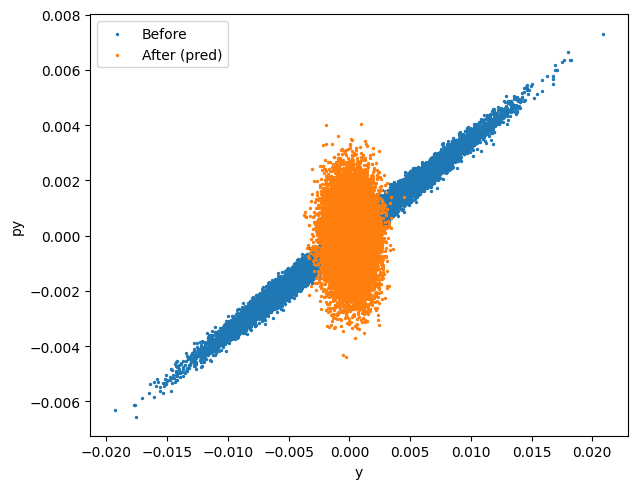

In [209]:
import matplotlib.pyplot as plt

Y_true = Y_val   # true transported states from xsuite
# or compare input vs predicted transport:
# z_in_raw = X_test[:, :6]
labels = ["x", "y", "zeta", "px", "py", "delta"]

index_1 = 1 # 0 for x, 1 for y, 2 for zeta
index_2 = index_1 +3

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(Y_val[:, index_1].cpu(), Y_val[:, index_2].cpu(), s=2, label="Before")
plt.scatter(Y_pred[:, index_1], Y_pred[:, index_2], s=2, label="After (pred)")
plt.xlabel(labels[index_1])
plt.ylabel(labels[index_2])
plt.legend()
#plt.title(f"Transport for kf1={kf1}, kq1={kq1}, kf2={kf2}")

plt.tight_layout()
plt.show()